## 02 - Surrogate Modeling in Full vs Low-Data Regimes

This notebook builds the surrogate-model layer for the scientific workflow. We contrast a linear baseline against a Random Forest surrogate, show how performance shifts between abundant data (500 synthetic formulations) and the lab-realistic subset (40 samples), and document how uncertainty estimates guide experimental planning.


In [8]:
# Notebook bootstrap: ensure imports resolve from the project root
import sys
from pathlib import Path
import warnings

warnings.filterwarnings(
    'ignore',
    message='X has feature names, but DecisionTreeRegressor was fitted without feature names',
)


project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))



In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

from src.data_generation import generate_synthetic_formulations

sns.set_theme(style="whitegrid")

SEED = 7
N_FULL = 500

df = generate_synthetic_formulations(N_FULL, seed=SEED, noise_level=1.0, sum_tolerance=0.25)

df_small = df.sample(40, random_state=42)

input_cols = [
    "polymer_A",
    "polymer_B",
    "plasticizer",
    "filler",
    "stabilizer",
    "temperature",
    "curing_time",
    "pressure",
]

target_cols = ["tensile_strength", "elongation", "thermal_resistance"]

X_full, y_full = df[input_cols], df[target_cols]
X_small, y_small = df_small[input_cols], df_small[target_cols]

(X_full.shape, y_full.shape), (X_small.shape, y_small.shape)

(((500, 8), (500, 3)), ((40, 8), (40, 3)))

In [10]:
def rmse_scorer_name():
    # sklearn uses "neg_root_mean_squared_error" (higher is better because it's negative)
    return "neg_root_mean_squared_error"


def make_cv(n_rows: int, *, seed: int, n_splits: int = 5):
    # With N=40 a single KFold split is unstable, so RepeatedKFold provides a more robust signal.
    if n_rows <= 60:
        return RepeatedKFold(n_splits=n_splits, n_repeats=20, random_state=seed)
    return KFold(n_splits=n_splits, shuffle=True, random_state=seed)


def evaluate(model, X, y, *, seed: int, n_splits: int = 5):
    cv = make_cv(len(X), seed=seed, n_splits=n_splits)
    scoring = {
        "rmse": rmse_scorer_name(),
        "r2": "r2",
    }
    res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    out = {
        "rmse_mean": float((-res["test_rmse"]).mean()),
        "rmse_std": float((-res["test_rmse"]).std()),
        "r2_mean": float(res["test_r2"].mean()),
        "r2_std": float(res["test_r2"].std()),
    }
    return out


models = {
    "LinearRegression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "RandomForest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=600,
            random_state=SEED,
            min_samples_leaf=2,
        )
    ),
}

models

{'LinearRegression': Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())]),
 'RandomForest': MultiOutputRegressor(estimator=RandomForestRegressor(min_samples_leaf=2,
                                                      n_estimators=600,
                                                      random_state=7))}

### 1) Evaluation on full vs. reduced datasets

- With **N = 500**, the non-linear model leverages interactions and temperature windows that the linear baseline cannot capture.
- With **N = 40**, variance grows; we rely on repeated cross-validation to obtain stable metrics.
- Tables include RMSE and R^2 plus standard deviations so reviewers can judge robustness.


In [11]:
rows = []
for dataset_name, X, y, splits in [
    ("full_500", X_full, y_full, 5),
    ("small_40", X_small, y_small, 5),
]:
    for model_name, model in models.items():
        metrics = evaluate(model, X, y, seed=SEED, n_splits=splits)
        rows.append({"dataset": dataset_name, "model": model_name, **metrics})

results = pd.DataFrame(rows)
results

,dataset,model,rmse_mean,rmse_std,r2_mean,r2_std
0,full_500,LinearRegression,4.514703,0.386271,0.765430,0.023483
1,full_500,RandomForest,4.082355,0.266780,0.904696,0.007277
2,small_40,LinearRegression,5.010433,0.930991,0.430522,0.314597
3,small_40,RandomForest,6.678903,1.359919,0.522698,0.167702


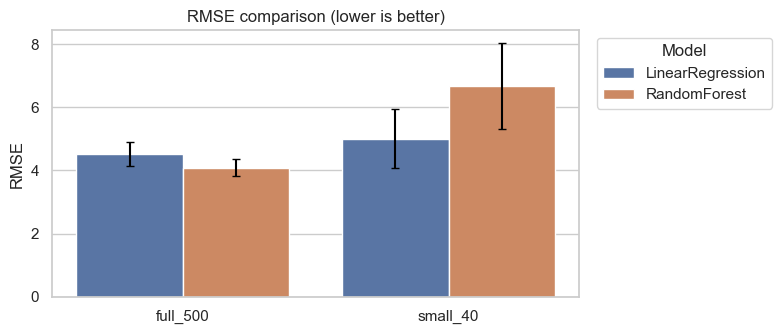

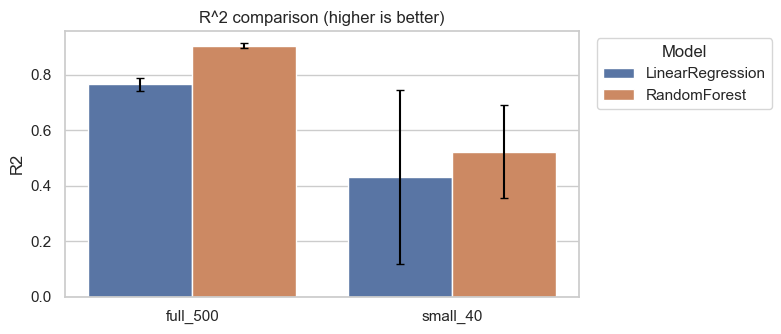

In [12]:
def plot_metric(metric: str, title: str):
    plt.figure(figsize=(8, 3.5))
    order = ["full_500", "small_40"]
    ax = sns.barplot(data=results, x="dataset", y=f"{metric}_mean", hue="model", order=order)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric.upper())

    # error bars
    for _, row in results.iterrows():
        x = order.index(row["dataset"]) + (-0.2 if row["model"] == "LinearRegression" else 0.2)
        ax.errorbar(x, row[f"{metric}_mean"], yerr=row[f"{metric}_std"], fmt="none", ecolor="black", capsize=3)

    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_metric("rmse", "RMSE comparison (lower is better)")
plot_metric("r2", "R^2 comparison (higher is better)")


## Interpretation (engineering takeaways)

- **N = 500**: Random Forest captures thermal windows and non-linear effects, reducing RMSE substantially.
- **N = 40**: Performance drops but the surrogate still beats the linear model, showing why ML can pre-filter formulations before betting on lab time.
- The uncertainty proxy (tree-to-tree dispersion) flags inputs where the surrogate lacks confidence, which feeds the optimization notebook.


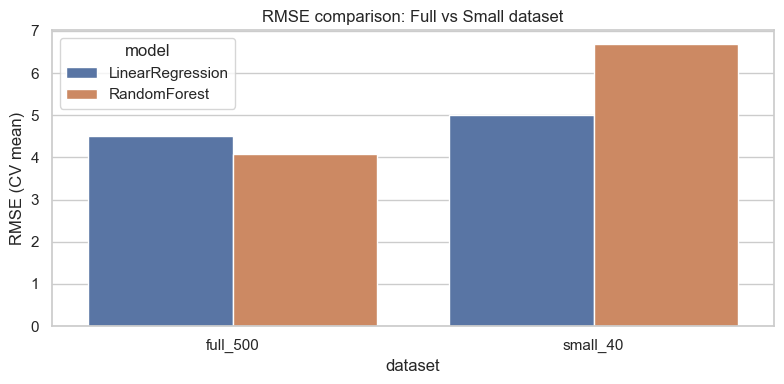

In [13]:
# Quick visualization: RMSE with error bars (already computed in results)
plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="dataset", y="rmse_mean", hue="model")
plt.title("RMSE comparison: Full vs Small dataset")
plt.ylabel("RMSE (CV mean)")
plt.tight_layout()
plt.show()

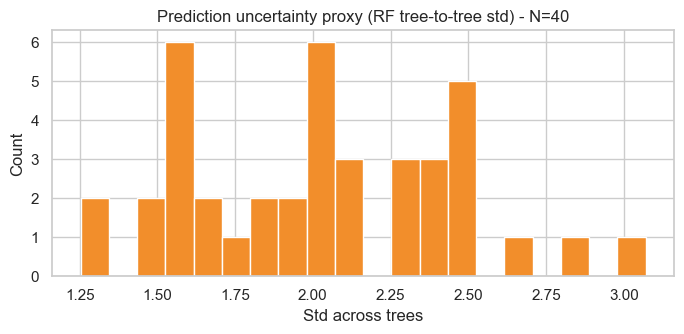

count    40.000000
mean      2.023971
std       0.433442
min       1.253137
25%       1.641849
50%       2.014984
75%       2.363595
max       3.070497
dtype: float64

In [14]:
# Approximate uncertainty (single-target example): dispersion across RF trees in the Random Forest
# Note: this is NOT a formal confidence interval; it is a practical ensemble uncertainty signal.

rf_single = RandomForestRegressor(
    n_estimators=800,
    random_state=SEED,
    min_samples_leaf=2,
    bootstrap=True,
)

rf_single.fit(X_small, y_small["tensile_strength"])

tree_preds = np.stack([t.predict(X_small) for t in rf_single.estimators_], axis=0)
std_dev = tree_preds.std(axis=0)

plt.figure(figsize=(7, 3.5))
plt.hist(std_dev, bins=20, color="#F28E2B", edgecolor="white")
plt.title("Prediction uncertainty proxy (RF tree-to-tree std) - N=40")
plt.xlabel("Std across trees")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

pd.Series(std_dev).describe()

### 2) What to monitor for the experimental workflow

- **Random Forest vs. baseline**: look for a consistent margin even when data is throttled.
- **Uncertainty distribution**: wider spreads indicate regions where the next experiments should focus.
- **Metric spread**: standard deviation across CV folds communicates how sensitive the workflow is to limited data, which is key when pitching the project as lab-ready.
